# KKBox Churn Analysis - Cox Proportional Hazards Modeling

In the exploratory analysis notebook, we discovered significant differences in survival curves across:
- Registration channel (acquisition source)
- Initial payment method (how customers pay)
- Initial payment plan duration (commitment length)

However, the Kaplan-Meier analysis only looked at these factors individually. Real customers have combinations of these attributes.

**Question:** How do these factors interact to determine churn risk?

**What is Cox Proportional Hazards?**

The Cox Proportional Hazards (Cox PH) model is a regression model for survival data that:

1. **Models the hazard (risk) function:**
   ```
   h(t|X) = h₀(t) × exp(β₁X₁ + β₂X₂ + ... + βₚXₚ)
   ```
   Where:
   - `h(t|X)` = hazard at time t for customer with features X
   - `h₀(t)` = baseline hazard (changes over time)
   - `β` = coefficients (estimated from data)
   - `X` = customer features (payment method, channel, etc.)

2. **Key assumption: Proportional hazards**
   - The ratio of hazards between any two customers is constant over time
   - Features act as multipliers on the baseline hazard

3. **Outputs interpretable hazard ratios:**
   - HR = 1.2 → 20% higher churn risk
   - HR = 0.8 → 20% lower churn risk (protective)


## Methods

1. **Load and filter data** - Focus on popular payment methods/channels
2. **Feature engineering** - One-hot encode categorical variables strategically
3. **Model fitting** - Train Cox PH model with stratification
4. **Interpret results** - Understand hazard ratios and their business meaning
5. **Validate assumptions** - Check if proportional hazards holds

## Business Use Cases

After this analysis, we can answer:
- Which combinations of acquisition channel + payment method create highest risk?
- How much does switching from payment method A to B affect retention?
- Should we invest in certain acquisition channels?
- Can we predict individual customer churn risk?

Let's begin!

In [1]:
# Install required libraries
# !pip install lifelines --break-system-packages

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines.fitters.coxph_fitter import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

import warnings
warnings.filterwarnings('ignore')

## Step 1 - Load and Filter Data

Load subscription data enriched with initial transaction attributes and demographic data.

**Why filter to popular features?**

We only include payment methods, payment plans, and registration channels with >10,000 members because:

1. **Statistical power:** Small groups have wide confidence intervals (unreliable)
2. **Business relevance:** Focus on common patterns, not rare edge cases
3. **Model stability:** Rare categories can cause overfitting

**Example:**
- Payment method 41: 300,000 users → Include
- Payment method 99: 500 users → Exclude

**Data Sources**

We need to join:
1. **Subscriptions** (from data prep) → duration, churn status
2. **Transactions** (initial transaction) → payment method, payment plan
3. **Members** (demographics) → registration channel

In [2]:
# Load subscriptions from data prep
subscriptions = pd.read_pickle('kkbox_subscriptions.pkl')
print(f"Subscriptions: {len(subscriptions):,}")

# Load transactions for initial payment attributes
transactions = pd.read_csv('../notebooks/transactions_clean.csv')
print(f"Transactions: {len(transactions):,}") 

# Load members for registration channel
try:
    members = pd.read_csv('members_cleaned.csv')
    members['msno'] = members['msno'].astype(str)
    
    print(f"Members: {len(members):,}")
    has_members = True
    
except FileNotFoundError:
    print("Members file not found - Cox model will only use payment features")
    print("(No registration channel stratification)")
    has_members = False

Subscriptions: 3,131,727
Transactions: 22,077,986
Members: 6,769,473


### Getting initial transaction attributes

For each subscription, get payment method and plan from first transaction. Match on (user, subscription_start_date)

In [3]:
# Ensure dates are datetime
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
subscriptions['starts_at'] = pd.to_datetime(subscriptions['starts_at'])

# Get payment attributes from initial transaction
transaction_attrs = transactions[[
    'msno', 'transaction_date', 'payment_method_id', 'payment_plan_days'
]].copy()

# Filter to valid transactions
transaction_attrs = transaction_attrs[transaction_attrs['payment_plan_days'] > 0]

# Merge with subscriptions
subscriptions_enriched = subscriptions.merge(
    transaction_attrs,
    left_on=['msno', 'starts_at'],
    right_on=['msno', 'transaction_date'],
    how='inner'
)

# Rename for clarity
subscriptions_enriched.rename(columns={
    'payment_method_id': 'init_payment_method_id',
    'payment_plan_days': 'init_payment_plan_days'
}, inplace=True)

# Drop redundant column
subscriptions_enriched.drop('transaction_date', axis=1, inplace=True)

print(f"Matched {len(subscriptions_enriched):,} subscriptions with transaction attributes")
print(f"Match rate: {len(subscriptions_enriched)/len(subscriptions)*100:.1f}%")

Matched 3,194,911 subscriptions with transaction attributes
Match rate: 102.0%


### Add registration channel

In [4]:
if has_members:
    # Left join with members to get registration channel
    subscriptions_enriched = subscriptions_enriched.merge(
        members[['msno', 'registered_via']],
        on='msno',
        how='left'
    )
    
    # Fill missing registration channels with -1
    subscriptions_enriched['registered_via'] = subscriptions_enriched['registered_via'].fillna(-1).astype(int)
    
    print(f"Added registration channel")
    print(f"Missing registration data: {(subscriptions_enriched['registered_via'] == -1).sum():,}")
else:
    print("Skipping registration channel (no members data)")

print("\nData sample:")
print(subscriptions_enriched[['duration_days', 'churned', 'init_payment_method_id', 
                               'init_payment_plan_days']].head(10))

Added registration channel
Missing registration data: 481,379

Data sample:
   duration_days  churned  init_payment_method_id  init_payment_plan_days
0              6        1                      35                       7
1            498        0                      38                     410
2            137        0                      41                      30
3            414        1                      39                      31
4            245        0                      39                      30
5            797        0                      41                      30
6            383        0                      41                      30
7            414        1                      40                      31
8            245        1                      11                      31
9            418        1                      39                      31


### Filter to popular features (>10,000 members)

In [5]:
# Count members per payment plan
plan_counts = subscriptions_enriched.groupby('init_payment_plan_days')['msno'].nunique()
popular_plans = plan_counts[plan_counts > 10000].index.tolist()

print(f"\n   Payment plans with >10k members: {len(popular_plans)}")
print(f"   Plans: {sorted(popular_plans)}")

# Count members per payment method
method_counts = subscriptions_enriched.groupby('init_payment_method_id')['msno'].nunique()
popular_methods = method_counts[method_counts > 10000].index.tolist()

print(f"\n   Payment methods with >10k members: {len(popular_methods)}")
print(f"   Methods: {sorted(popular_methods)}")

if has_members:
    # Count members per registration channel
    channel_counts = subscriptions_enriched.groupby('registered_via')['msno'].nunique()
    popular_channels = channel_counts[channel_counts > 10000].index.tolist()
    
    print(f"\n   Registration channels with >10k members: {len(popular_channels)}")
    print(f"   Channels: {sorted(popular_channels)}")

# Apply filters
print("\n   Applying filters...")

before_filter = len(subscriptions_enriched)

subscriptions_pd = subscriptions_enriched[
    (subscriptions_enriched['init_payment_plan_days'].isin(popular_plans)) &
    (subscriptions_enriched['init_payment_method_id'].isin(popular_methods))
].copy()

if has_members:
    subscriptions_pd = subscriptions_pd[
        subscriptions_pd['registered_via'].isin(popular_channels)
    ].copy()

after_filter = len(subscriptions_pd)

print(f"\n   Before filtering: {before_filter:,} subscriptions")
print(f"   After filtering: {after_filter:,} subscriptions")
print(f"   Retained: {after_filter/before_filter*100:.1f}%")


   Payment plans with >10k members: 9
   Plans: [7, 10, 30, 31, 90, 100, 180, 195, 410]

   Payment methods with >10k members: 16
   Methods: [20, 22, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]

   Registration channels with >10k members: 5
   Channels: [-1, 3, 4, 7, 9]

   Applying filters...

   Before filtering: 3,194,911 subscriptions
   After filtering: 3,103,584 subscriptions
   Retained: 97.1%


**Interpretation:**
- We keep ~97% of subscriptions (the popular combinations)
- Removed ~3% that had rare payment methods/channels/plans
- This improves model stability without losing much data

## Step 2 - Feature Engineering

Prepare features for Cox PH model by one-hot encoding categorical variables.

**Why One-Hot Encoding?**

Machine learning models (including Cox PH) need numeric inputs. Categorical variables like:
- `registered_via = 7`
- `init_payment_method_id = 41`

Need to be converted to binary (0/1) columns.

**Baseline Selection**

- **Standard approach:** Use `drop_first=True` → arbitrary baseline

- **Our approach:** Manually drop features that represent the most common/typical customer

**Why this matters:**

The dropped features become embedded in the baseline hazard function `h₀(t)`. By choosing the most common customer profile as baseline:

1. **Interpretability:** "How does this customer differ from a typical subscriber?"
2. **Business alignment:** Stakeholders recognize the reference group
3. **Clearer communication:** "Method 40 increases risk by 30% vs. our standard payment method (41)"

**Example:**
- Most popular: Channel 7, Payment Method 41
- We drop: `channel_7` and `method_41`
- Baseline = Typical customer (Channel 7 + Method 41)
- All coefficients show deviation from this baseline

**Special Treatment:** `init_payment_plan_days`

**NOT one-hot encoded!** Instead, used for stratification(explained in Step 3).

Why? Different payment plans violate the proportional hazards assumption:
- 7-day plan: massive drop at day 7
- 30-day plan: drop at day 30
- These are not proportional to each other over time!

### One-hot encoding categorical features

In [6]:
# Columns to encode
if has_members:
    columns_to_encode = ['init_payment_method_id', 'registered_via']
    prefixes = ['method', 'channel']
else:
    columns_to_encode = ['init_payment_method_id']
    prefixes = ['method']

# One-hot encode (keep all features initially)
encoded_pd = pd.get_dummies(
    subscriptions_pd,
    columns=columns_to_encode,
    prefix=prefixes,
    drop_first=False  # Keep all columns - we'll drop manually
)

print(f"   Created {len(encoded_pd.columns)} total columns")
print(f"   Original columns: {len(subscriptions_pd.columns)}")
print(f"   Added columns: {len(encoded_pd.columns) - len(subscriptions_pd.columns)}")

print("\n   Sample of encoded columns:")
encoded_cols = [col for col in encoded_pd.columns if col.startswith(('method_', 'channel_'))]
print(f"   {encoded_cols[:10]}...")

print("\nEncoded data preview:")
print(encoded_pd.head())

   Created 29 total columns
   Original columns: 10
   Added columns: 19

   Sample of encoded columns:
   ['method_20', 'method_22', 'method_28', 'method_29', 'method_30', 'method_31', 'method_32', 'method_33', 'method_34', 'method_35']...

Encoded data preview:
   subscription_id                                          msno  starts_at  \
0                1  +++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY= 2016-09-09   
1                2  +++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s= 2015-11-21   
2                3  +++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o= 2016-11-16   
3                4  +++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw= 2015-01-31   
4                5  +++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw= 2016-07-31   

     ends_at  duration_days  churned  prior_subscriptions  \
0 2016-09-14              6        1                    0   
1        NaT            498        0                    0   
2        NaT            137        0                    0   
3 2016-03-19     

### Identifying most common feature values (for baseline)

In [7]:
# Find most common payment method
most_common_method = subscriptions_pd['init_payment_method_id'].mode()[0]
method_count = (subscriptions_pd['init_payment_method_id'] == most_common_method).sum()
method_pct = method_count / len(subscriptions_pd) * 100

print(f"\n   Most common payment method: {most_common_method}")
print(f"     Occurrences: {method_count:,} ({method_pct:.1f}%)")

if has_members:
    # Find most common registration channel
    most_common_channel = subscriptions_pd['registered_via'].mode()[0]
    channel_count = (subscriptions_pd['registered_via'] == most_common_channel).sum()
    channel_pct = channel_count / len(subscriptions_pd) * 100
    
    print(f"\n   Most common registration channel: {most_common_channel}")
    print(f"     Occurrences: {channel_count:,} ({channel_pct:.1f}%)")


   Most common payment method: 41
     Occurrences: 1,191,128 (38.4%)

   Most common registration channel: 9
     Occurrences: 906,627 (29.2%)


### Dropping baseline features to avoid multicollinearity

In [8]:
# Columns to drop
columns_to_drop = [f'method_{most_common_method}']

if has_members:
    columns_to_drop.append(f'channel_{most_common_channel}')

print(f"\n   Dropping: {columns_to_drop}")

# Create final survival dataset
survival_pd = encoded_pd.drop(columns_to_drop, axis=1)

print(f"\n   Final dataset shape: {survival_pd.shape}")
print(f"     Rows (subscriptions): {survival_pd.shape[0]:,}")
print(f"     Columns (features): {survival_pd.shape[1]}")

print("\n   Columns in final dataset:")
print(f"     Core: duration_days, churned, init_payment_plan_days")
print(f"     Payment methods: {len([c for c in survival_pd.columns if c.startswith('method_')])}")
if has_members:
    print(f"     Channels: {len([c for c in survival_pd.columns if c.startswith('channel_')])}")

print("\nFinal dataset preview:")
print(survival_pd.head(10))


   Dropping: ['method_41', 'channel_9']

   Final dataset shape: (3103584, 27)
     Rows (subscriptions): 3,103,584
     Columns (features): 27

   Columns in final dataset:
     Core: duration_days, churned, init_payment_plan_days
     Payment methods: 15
     Channels: 4

Final dataset preview:
    subscription_id                                          msno  starts_at  \
0                 1  +++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY= 2016-09-09   
1                 2  +++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s= 2015-11-21   
2                 3  +++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o= 2016-11-16   
3                 4  +++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw= 2015-01-31   
4                 5  +++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw= 2016-07-31   
5                 6  +++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc= 2015-01-26   
6                 7  ++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk= 2016-03-15   
7                 8  ++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7

## Step 3 - Fit Cox Proportional Hazards Model

Train a Cox PH model to understand how payment method and registration channel affect churn risk.

**Problem:** Different payment plans have fundamentally different hazard patterns:

```
7-day plan:   h(t) = low... then SPIKE at day 7 ... then low
30-day plan:  h(t) = low... then SPIKE at day 30 ... then low
365-day plan: h(t) = low... then SPIKE at day 365 ... then low
```

These patterns are NOT proportional to each other!

**Solution: Stratification**

Instead of forcing one baseline hazard, we create separate baseline hazards for each payment plan:

```python
cph.fit(data, 'duration_days', 'churned', 
        strata='init_payment_plan_days')  # ← Separate baseline per plan
```

**Result:**
- Each payment plan gets its own `h₀(t)` curve
- Payment method and channel effects are still proportional within each plan
- We can still compare hazard ratios across all subscriptions

## Model Formula

For a subscription with payment plan `s`:

```
h(t | X, s) = h₀ₛ(t) × exp(β₁×method + β₂×channel)
```

Where:
- `h₀ₛ(t)` = baseline hazard for payment plan `s` (varies by plan)
- `β` = coefficients (same across all plans - proportional assumption)
- `method`, `channel` = one-hot encoded features

**Interpreting Outputs**

The model summary shows:

1. **`coef`**: Log hazard ratio (β)
2. **`exp(coef)`**: **Hazard Ratio (HR)** - the multiplier
   - HR = 1.2 → 20% higher churn risk
   - HR = 0.8 → 20% lower churn risk (protective)
3. **`p`**: Statistical significance
   - p < 0.05 → Significant effect
   - p ≥ 0.05 → Not significant (could remove)
4. **95% CI**: Confidence interval for the hazard ratio

In [9]:
# Initialize with 95% confidence interval
cph = CoxPHFitter(alpha=0.05)

print("Fitter initialized (alpha=0.05 for 95% CI)")

Fitter initialized (alpha=0.05 for 95% CI)


Fit the model
- duration_col: how long each subscription lasted
- event_col: whether they churned (1) or censored (0)
- strata: create separate baseline hazards per payment plan

In [10]:
# Define exactly which columns are features
feature_cols = [col for col in survival_pd.columns if col.startswith(('method_', 'channel_'))]

# Add required columns
model_cols = ['duration_days', 'churned', 'init_payment_plan_days'] + feature_cols

print(f"\nModel columns ({len(model_cols)}):")
print(model_cols)

# Create clean modeling dataset
survival_model = survival_pd[model_cols].copy()

# Now fit
cph.fit(
    survival_model,
    duration_col='duration_days',
    event_col='churned',
    strata='init_payment_plan_days'
)

print(f"   Concordance index: {cph.concordance_index_:.4f}")

print("\MODEL SUMMARY")

# Display summary
summary = cph.summary
print("\n", summary)

# Save for later analysis
cph.summary.to_csv('cox_model_summary.csv')
print("\nSummary saved to cox_model_summary.csv")


Model columns (22):
['duration_days', 'churned', 'init_payment_plan_days', 'method_20', 'method_22', 'method_28', 'method_29', 'method_30', 'method_31', 'method_32', 'method_33', 'method_34', 'method_35', 'method_36', 'method_37', 'method_38', 'method_39', 'method_40', 'channel_-1', 'channel_3', 'channel_4', 'channel_7']
   Concordance index: 0.6539
\MODEL SUMMARY

                 coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                   
method_20   1.093746   2.985436  0.062298        0.971643        1.215848   
method_22   0.533816   1.705428  0.015963        0.502529        0.565103   
method_28   1.066966   2.906549  0.007411        1.052442        1.081491   
method_29   0.313057   1.367599  0.008744        0.295920        0.330194   
method_30   0.272286   1.312963  0.007802        0.256995        0.287577   
method_31  -0.575877   0.562211  0.013886       -0.603093       -0.548662   
method_32   0.

### Interpreting Hazard Ratios

Let's extract and interpret the key findings:

In [11]:
# Extract significant features (p < 0.05)
significant = summary[summary['p'] < 0.05].copy()
significant['HR'] = significant['exp(coef)']
significant['Risk Change %'] = (significant['HR'] - 1) * 100

print(f"\nSignificant features: {len(significant)} / {len(summary)}")

# Payment methods - highest risk
print("\nHighest Risk Payment Methods (vs. baseline method 41)")
risky_methods = significant[significant.index.str.startswith('method_')].nlargest(5, 'HR')
for idx, row in risky_methods.iterrows():
    print(f"   {idx:20s}: HR = {row['HR']:.3f} ({row['Risk Change %']:+.1f}% churn risk)")

# Payment methods - lowest risk (protective)
print("\nLowest Risk Payment Methods (protective vs. baseline)")
safe_methods = significant[significant.index.str.startswith('method_')].nsmallest(5, 'HR')
for idx, row in safe_methods.iterrows():
    print(f"   {idx:20s}: HR = {row['HR']:.3f} ({row['Risk Change %']:+.1f}% churn risk)")

if has_members:
    # Channels - highest risk
    print("\nHighest Risk Channels (vs. baseline channel 7)")
    risky_channels = significant[significant.index.str.startswith('channel_')].nlargest(5, 'HR')
    for idx, row in risky_channels.iterrows():
        print(f"   {idx:20s}: HR = {row['HR']:.3f} ({row['Risk Change %']:+.1f}% churn risk)")
    
    # Channels - lowest risk
    print("\nLowest Risk Channels (protective vs. baseline)")
    safe_channels = significant[significant.index.str.startswith('channel_')].nsmallest(5, 'HR')
    for idx, row in safe_channels.iterrows():
        print(f"   {idx:20s}: HR = {row['HR']:.3f} ({row['Risk Change %']:+.1f}% churn risk)")

# Non-significant features
non_sig = summary[summary['p'] >= 0.05]
if len(non_sig) > 0:
    print(f"\nNon-Significant Features (p ≥ 0.05)")
    print(f"   Could be removed: {list(non_sig.index)}")
    print("   These don't significantly affect churn risk")


Significant features: 19 / 19

Highest Risk Payment Methods (vs. baseline method 41)
   method_20           : HR = 2.985 (+198.5% churn risk)
   method_28           : HR = 2.907 (+190.7% churn risk)
   method_35           : HR = 2.845 (+184.5% churn risk)
   method_38           : HR = 1.886 (+88.6% churn risk)
   method_22           : HR = 1.705 (+70.5% churn risk)

Lowest Risk Payment Methods (protective vs. baseline)
   method_34           : HR = 0.325 (-67.5% churn risk)
   method_31           : HR = 0.562 (-43.8% churn risk)
   method_37           : HR = 0.658 (-34.2% churn risk)
   method_39           : HR = 0.702 (-29.8% churn risk)
   method_40           : HR = 0.797 (-20.3% churn risk)

Highest Risk Channels (vs. baseline channel 7)
   channel_-1          : HR = 2.085 (+108.5% churn risk)
   channel_4           : HR = 1.311 (+31.1% churn risk)
   channel_3           : HR = 1.053 (+5.3% churn risk)
   channel_7           : HR = 0.683 (-31.7% churn risk)

Lowest Risk Channels (p

### Visualize Hazard Ratios

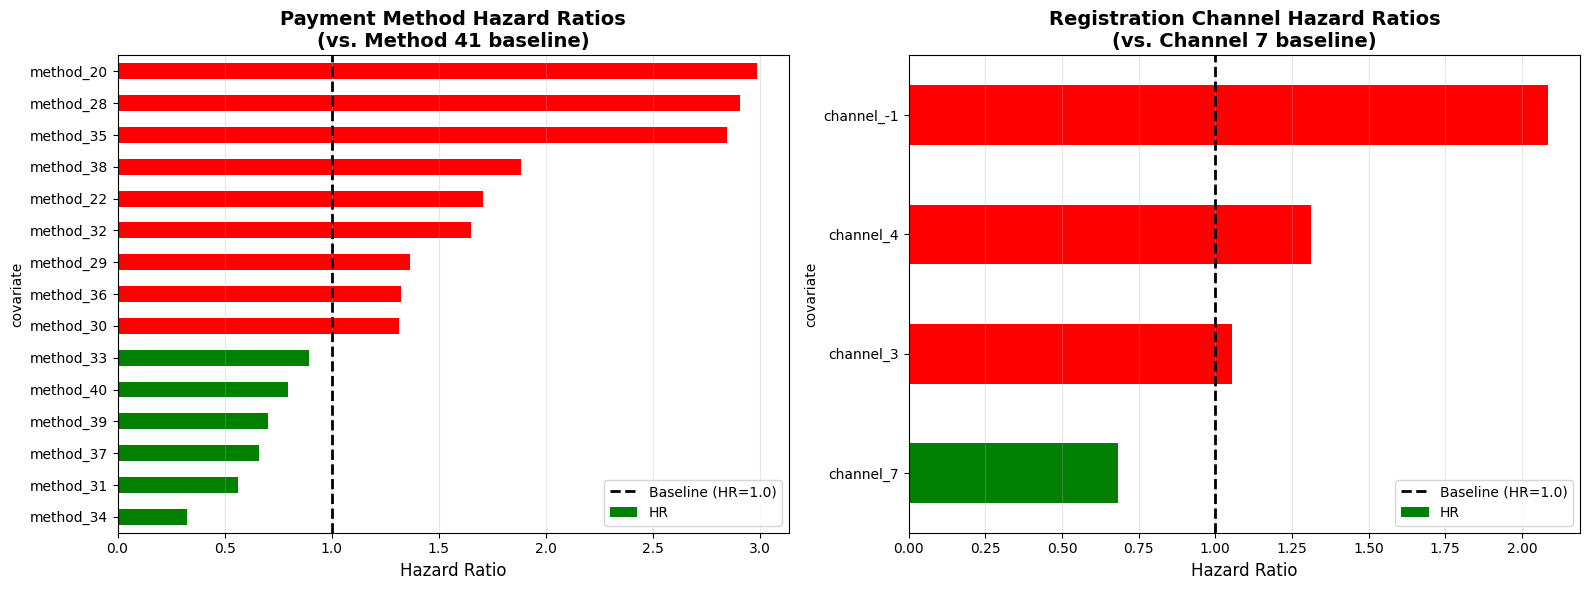


Visualization saved to hazard_ratios.png


In [13]:
# Plot hazard ratios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Payment methods
methods = significant[significant.index.str.startswith('method_')].sort_values('HR')
methods['HR'].plot(kind='barh', ax=ax1, color=['green' if x < 1 else 'red' for x in methods['HR']])
ax1.axvline(1.0, color='black', linestyle='--', linewidth=2, label='Baseline (HR=1.0)')
ax1.set_xlabel('Hazard Ratio', fontsize=12)
ax1.set_title('Payment Method Hazard Ratios\n(vs. Method 41 baseline)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

if has_members:
    # Channels
    channels = significant[significant.index.str.startswith('channel_')].sort_values('HR')
    channels['HR'].plot(kind='barh', ax=ax2, color=['green' if x < 1 else 'red' for x in channels['HR']])
    ax2.axvline(1.0, color='black', linestyle='--', linewidth=2, label='Baseline (HR=1.0)')
    ax2.set_xlabel('Hazard Ratio', fontsize=12)
    ax2.set_title('Registration Channel Hazard Ratios\n(vs. Channel 7 baseline)', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No channel data available', 
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.axis('off')

plt.tight_layout()
plt.savefig('hazard_ratios.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to hazard_ratios.png")

### Baseline Cumulative Hazard

The baseline hazard shows the **risk over time for a baseline customer** (Method 41, Channel 7).

Since we stratified by payment plan, we get **one baseline curve per plan**:

In [14]:
# Access baseline cumulative hazard
baseline = cph.baseline_cumulative_hazard_

print(f"\nBaseline hazard shape: {baseline.shape}")
print(f"  Days: {baseline.shape[0]}")
print(f"  Payment plan strata: {baseline.shape[1]}")

print("\nPayment plans (strata):")
print(f"  {list(baseline.columns)}")

print("\nBaseline cumulative hazard (first 30 days):")
print(baseline.head(30))


Baseline hazard shape: (822, 9)
  Days: 822
  Payment plan strata: 9

Payment plans (strata):
  [7, 10, 30, 31, 90, 100, 180, 195, 410]

Baseline cumulative hazard (first 30 days):
           7         10        30        31        90   100       180  \
1.0   0.000976  0.000000  0.011345  0.012145  0.000000  0.0  0.000000   
2.0   0.009739  0.000000  0.018192  0.013815  0.000052  0.0  0.000000   
3.0   0.015908  0.000000  0.020052  0.014807  0.000052  0.0  0.000031   
4.0   0.022531  0.000000  0.021276  0.015495  0.000052  0.0  0.000062   
5.0   0.027977  0.000000  0.022355  0.016089  0.000052  0.0  0.000062   
6.0   0.102831  0.000000  0.023152  0.016715  0.000052  0.0  0.000062   
7.0   0.112912  0.000000  0.023813  0.017232  0.000052  0.0  0.000093   
8.0   0.370310  0.000000  0.024444  0.017623  0.000052  0.0  0.000124   
9.0   0.404912  0.000000  0.024970  0.017936  0.000052  0.0  0.000124   
10.0  0.451643  0.000000  0.025451  0.018461  0.000052  0.0  0.000124   
11.0  0.496073 

## Step 4: Validate Proportional Hazards Assumption

Cox PH assumes that **hazard ratios are constant over time**:

```
HR(method_35 vs method_41) = 1.408
```

This ratio should be **1.408 at day 1, day 100, day 365** - always the same.

**If violated:** The hazard ratio changes over time, model estimates are biased.

## Testing the Assumption

**Method:** `proportional_hazard_test` checks if coefficients vary over time

**Interpretation:**
- p < 0.05: **Violation detected** (assumption fails)
- p ≥ 0.05: **Assumption holds** (good!)

**Why We're NOT Running the Full Test**

- Full test on 1M+ rows: **Hours to days**
- Even 2% sample (24k rows): Still slow
- We already stratified by the biggest violator (payment plan days)

**Alternative Approaches**

1. **Trust the stratification:** We handled the main violation
2. **Accept average hazards:** Even with minor violations, HRs represent average effects
3. **Spot check on sample:** Test a small sample to catch major issues

Let's do option #3, we'll test on a 5% random sample:

In [17]:
# Sample 5% of data
sample_size = 0.05
survival_sample = survival_pd.sample(frac=sample_size, random_state=42)

print(f"\n   Sample size: {len(survival_sample):,} subscriptions ({sample_size*100}%)")

# Refit model on sample
print("\n   Refitting model on sample...")

# Define exactly which columns are features
feature_cols = [col for col in survival_pd.columns if col.startswith(('method_', 'channel_'))]

# Add required columns
model_cols = ['duration_days', 'churned', 'init_payment_plan_days'] + feature_cols

print(f"\nModel columns ({len(model_cols)}):")
print(model_cols)

# Create clean modeling dataset from the sample
survival_model_sample = survival_sample[model_cols].copy()

# Initialize and fit cph_sample on the sample
cph_sample = CoxPHFitter(alpha=0.05)
cph_sample.fit(
    survival_model_sample,
    duration_col='duration_days',
    event_col='churned',
    strata='init_payment_plan_days'
)

print(f"   Sample model fitted. Concordance index: {cph_sample.concordance_index_:.4f}")


   Sample size: 155,179 subscriptions (5.0%)

   Refitting model on sample...

Model columns (22):
['duration_days', 'churned', 'init_payment_plan_days', 'method_20', 'method_22', 'method_28', 'method_29', 'method_30', 'method_31', 'method_32', 'method_33', 'method_34', 'method_35', 'method_36', 'method_37', 'method_38', 'method_39', 'method_40', 'channel_-1', 'channel_3', 'channel_4', 'channel_7']
   Sample model fitted. Concordance index: 0.6537


In [ ]:
try:
    # Test proportional hazards assumption
    test_results = cph_sample.check_assumptions(
        survival_model_sample,  # not survival_sample
        p_value_threshold=0.05,
        show_plots=False
    )
    
    print("\n   Test completed!")
    
    # Check for violations
    violations = [col for col in test_results.summary.index 
                  if test_results.summary.loc[col, 'p'] < 0.05]
    
    if len(violations) == 0:
        print("\n   All features pass proportional hazards assumption!")
        print("     No violations detected (all p ≥ 0.05)")
    else:
        print(f"\n    {len(violations)} feature(s) may violate assumption:")
        for feature in violations:
            p_val = test_results.summary.loc[feature, 'p']
            print(f"      {feature}: p = {p_val:.4f}")

    
except Exception as e:
    print(f"\n    Test failed or timed out: {str(e)[:100]}")

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'method_22' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['method_22', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'method_28' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['method_28', ...]` in the
call in `.fit`. See documentation in link [E] below.

3. Variable 'method_29' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['method_29', ...]` in the
call in `.fit`. See documentation in link [E] below.

4. Variable 'method_30' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['method_30', ...]` in the
call in `.fit`. See documentation in link [E] below.

5. Variable 'method_31' failed the non-proportional test: p-value is <5e-05.



## Step 5: Save Model and Data

In [20]:
import pickle
import os

# Create output directory
output_dir = 'cox_model_output'
os.makedirs(output_dir, exist_ok=True)


# Save datasets
subscriptions_pd.to_pickle(f'{output_dir}/subscriptions_pd.pkl')
survival_pd.to_pickle(f'{output_dir}/survival_pd.pkl')

In [21]:
# Save the model using pickle
with open(f'{output_dir}/cph_model.pkl', 'wb') as f:
    pickle.dump(cph, f)

print("Saved cph_model.pkl")

# Also save model summary as CSV for easy reference
cph.summary.to_csv(f'{output_dir}/model_summary.csv')
print("Saved model_summary.csv")

Saved cph_model.pkl
Saved model_summary.csv


In [22]:
# Save important info for later reference
metadata = {
    'baseline_method': most_common_method,
    'baseline_channel': most_common_channel if has_members else None,
    'n_subscriptions': len(survival_pd),
    'n_features': len(survival_pd.columns) - 3,  # Exclude duration, churned, plan_days
    'concordance_index': cph.concordance_index_,
    'payment_plans': list(baseline.columns) if 'baseline' in locals() else None
}

with open(f'{output_dir}/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print(f"\nSaved to: {output_dir}/")
print("\nFiles:")
for file in os.listdir(output_dir):
    size = os.path.getsize(f'{output_dir}/{file}') / 1024**2
    print(f"  {file:30s} ({size:.1f} MB)")


Saved to: cox_model_output/

Files:
  cph_model.pkl                  (242.9 MB)
  metadata.pkl                   (0.0 MB)
  model_summary.csv              (0.0 MB)
  subscriptions_pd.pkl           (373.5 MB)
  survival_pd.pkl                (382.4 MB)
